# Importing dependencies

In [214]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [215]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [216]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [217]:
figures_dir = os.path.join('./figures/')

os.system('mkdir -p ' + figures_dir)

0

# Loading the cases

In [218]:
cases = pd.read_excel('Experimento_bancada.xlsx', 'experimentos_adaptado')
display(cases)

,Case,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Feed salinity at the inlet (g/L),Barium concentration at the inlet (g/L),Membrane thickness (m),Membrane porosity,Pore diameter (m),Polymer conductivity (W/mK),Membrane area (m²),...,Coolant salinity at the inlet (g/L),Number of channels,Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Distilled water flux (L/m²h),Distilled water flux (L/h),Distilled water flux (L/m²h) 2,Distilled water flux uncertainty (L/m²h)
0,Case 1,60.71,40.81,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,60.66,0.19,41.54,0.21,31.831016,0.250,50.0,0
1,Case 2,50.03,30.66,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,49.64,0.19,31.42,0.21,5.856907,0.046,9.2,0
2,Case 3,51.12,30.78,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,50.78,0.19,31.56,0.21,5.984231,0.047,9.4,0
3,Case 4,40.26,22.16,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,39.91,0.19,22.71,0.21,4.456342,0.035,7.0,0
4,Case 5,60.33,40.50,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,60.04,0.19,41.34,0.21,8.912684,0.070,14.0,0
5,Case 6,40.18,20.07,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,39.82,0.19,20.74,0.21,4.710990,0.037,7.4,0
6,Case 7,40.24,19.81,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,39.75,0.19,20.52,0.21,3.565074,0.028,5.6,0
7,Case 8,59.74,39.86,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,59.41,0.19,40.99,0.21,34.886793,0.274,54.8,0
8,Case 9,50.39,30.02,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,50.17,0.19,30.71,0.21,6.366203,0.050,10.0,0
9,Case 10,50.41,30.67,0.3,0,0.00015,0.7,3.500000e-07,0.3,0.007854,...,0.3,1,49.53,0.19,31.62,0.21,5.602259,0.044,8.8,0


# Running the cases

In [219]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [220]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Distillate flow rate (L/h)', 'Exp. permeate flux (L/m²h)', 'Exp. distillate flow rate (L/h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = elem['Vacuum pressure (Pa)']
    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(salinity_equation, initial_guess, args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)']))[0]
    initial_guess = elem['Coolant salinity at the inlet (g/L)'] / 1000.0
    cool_salinity = fsolve(salinity_equation, initial_guess, args=(elem['Coolant salinity at the inlet (g/L)'], elem['Coolant temperature at the inlet (°C)']))[0]
    BaCl2_concentration = elem['Barium concentration at the inlet (g/L)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * elem['Feed flow rate (L/h)'] / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * elem['Coolant flow rate (L/h)'] / 3600000.0
    membrane_area = elem['Membrane area (m²)']
    membrane_thickness = elem['Membrane thickness (m)']
    membrane_porosity = elem['Membrane porosity']
    pore_diameter = elem['Pore diameter (m)']
    polymer_conductivity = elem['Polymer conductivity (W/mK)']
    feed_channel_height = elem['Feed channel height (m)']
    cold_channel_height = elem['Cold channel height (m)']
    channel_width = elem['Channel width (m)']
    spacer_porosity = elem['Spacer porosity']
    gap_spacer_porosity = elem['Gap spacer porosity']
    air_gap_thickness = elem['Air gap thickness (m)']
    wall_thickness = elem['Wall thickness (m)']
    spacer_conductivity = elem['Spacer thermal conductivity (W/mK)']
    wall_conductivity = elem['Condensing wall thermal conductivity (W/mK)']
    number_channels = elem['Number of channels']
    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -BaCl2_concentration ' + str(BaCl2_concentration) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels) +
              ' -wall_conductivity ' + str(wall_conductivity) +
              ' -spacer_conductivity ' + str(spacer_conductivity) +
              ' -wall_thickness ' + str(wall_thickness) +
              ' -air_gap_thickness ' + str(air_gap_thickness) +
              ' -gap_spacer_porosity ' + str(gap_spacer_porosity) +
              ' -spacer_porosity ' + str(spacer_porosity) +
              ' -channel_width ' + str(channel_width) +
              ' -feed_channel_height ' + str(feed_channel_height) +
              ' -cold_channel_height ' + str(cold_channel_height) +
              ' -polymer_conductivity ' + str(polymer_conductivity) +
              ' -pore_diameter ' + str(pore_diameter) +
              ' -membrane_porosity ' + str(membrane_porosity) +
              ' -membrane_thickness ' + str(membrane_thickness))

    report = pd.read_csv('./results/report.csv', header=None)
    mass_flux = report[report[0] == 'Mass flux ='][1].values[0]
    distillate_flow_rate = report[report[0] == 'Distillate flow rate ='][1].values[0]
    film_temperature = report[report[0] == 'Temperature at the interface between the gap and the distillate film ='][1].values[0]
    hot_feedwater_outlet_temperature = report[report[0] == 'Feed temperature at the outlet of the module ='][1].values[0]
    cold_feedwater_outlet_temperature = report[report[0] == 'Coolant temperature at the outlet of the module ='][1].values[0]
    heat_flux = report[report[0] == 'Heat flux ='][1].values[0]
    vapor_heat_flux = report[report[0] == 'Vapor heat flux ='][1].values[0]
    GOR = report[report[0] == 'Gain-output ratio (GOR) ='][1].values[0]
    STECth = report[report[0] == 'Specific thermal energy consumption (SECth) ='][1].values[0]
    thermal_efficiency = report[report[0] == 'Thermal efficiency ='][1].values[0]
    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Distillate flow rate (L/h)': distillate_flow_rate,
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Exp. distillate flow rate (L/h)': elem['Distilled water flux (L/h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)

Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L
Salinity =  0.3  g/L


In [ ]:
display(results)
#results.to_csv('./teste_air_gap/results.csv', index=False)

,Case,Permeate flux (L/m²h),Distillate flow rate (L/h),Exp. permeate flux (L/m²h),Exp. distillate flow rate (L/h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,Case 1,4.049556,0.031917,31.831016,0.25,60.154252,60.66,41.365995,41.54,3470.521829,2629.687689,0.028744,30078.588171,75.772112
1,Case 2,2.377384,0.018725,5.856907,0.046,49.7124,49.64,30.977381,31.42,2425.821551,1566.011216,0.016668,61522.464245,64.555912
2,Case 3,2.581932,0.02034,5.984231,0.047,50.779418,50.78,31.120358,31.56,2600.112949,1698.866601,0.017029,59436.873764,65.338185
3,Case 4,1.373573,0.01081,4.456342,0.035,40.068378,39.91,22.35132,22.71,1736.16683,915.64971,0.010694,118503.388124,52.739731
4,Case 5,4.025539,0.031727,8.912684,0.07,59.944086,60.04,40.886071,41.34,3466.033858,2615.221611,0.019857,43735.302379,75.452858
5,Case 6,1.444537,0.01137,4.71099,0.037,39.935729,39.82,20.313816,20.74,1873.624614,963.51077,0.012288,105783.995264,51.424963
6,Case 7,1.453622,0.011442,3.565074,0.028,39.939967,39.75,20.109464,20.52,1890.484274,969.616551,0.014895,87501.121591,51.289321
7,Case 8,3.904016,0.030768,34.886793,0.274,59.294118,59.41,40.306033,40.99,3390.980899,2538.478721,0.022953,38158.546514,74.859717
8,Case 9,2.496499,0.019666,6.366203,0.05,50.107229,50.17,30.30256,30.71,2550.910394,1644.209002,0.014076,72941.103706,64.455773
9,Case 10,2.430606,0.019145,5.602259,0.044,50.016311,49.53,31.063422,31.62,2469.800894,1600.540523,0.020348,50188.695182,64.804435


In [222]:
100.0 * (results['Distillate flow rate (L/h)'] - results['Exp. distillate flow rate (L/h)']) / results['Exp. distillate flow rate (L/h)']

0    -87.233337
1    -59.293785
2     -56.72442
3    -69.114421
4    -54.676124
5    -69.270965
6    -59.137371
7    -88.770658
8    -60.668935
9    -56.488312
10   -56.864808
11   -70.741283
12   -43.481544
13   -57.787028
14    -48.63795
15   -65.144404
16   -60.007967
17   -63.791322
18   -52.376137
19   -61.285198
20   -41.505266
21    -50.34099
22   -54.280953
23   -60.550936
24   -62.267618
25   -67.947397
26   -44.472598
27   -46.633047
28   -52.033844
29    -84.10002
30   -61.900681
31   -62.516781
32   -55.525087
33   -68.601501
34   -64.402464
35   -52.469284
36   -22.911522
37   -32.445877
38    -6.222351
39   -29.524719
40    -3.734615
41   -37.434911
dtype: object

# Plot the results for different salinities

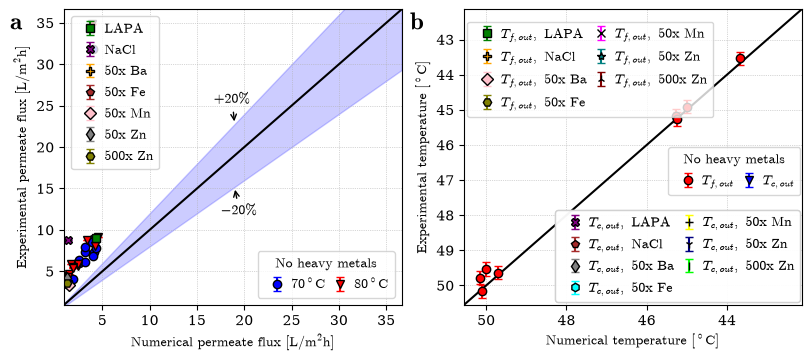

In [223]:
min_mass_flux = np.amin([0.75 * np.amin(results['Permeate flux (L/m²h)']), 0.75 * np.amin(results['Exp. permeate flux (L/m²h)'])])
max_mass_flux = np.amax([1.05 * np.amax(results['Permeate flux (L/m²h)']), 1.05 * np.amax(results['Exp. permeate flux (L/m²h)'])])

max_temperature = np.amin([1.1 * np.amin(results['Hot feedwater outlet temperature (°C)']), 1.1 * np.amin(results['Exp. hot feedwater outlet temperature (°C)'])])
min_temperature = np.amax([0.8 * np.amax(results['Cold feedwater outlet temperature (°C)']), 0.8 * np.amax(results['Exp. cold feedwater outlet temperature (°C)'])])

mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

axsval[0].errorbar(results['Permeate flux (L/m²h)'][:28:2],
                   results['Exp. permeate flux (L/m²h)'][:28:2],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][:28:2],
                   marker=markers[0], markersize=marker_size, markeredgecolor='black', color=colors[0], capsize=cap_size, label=r'$70^\circ \mathrm{C}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][1:29:2],
                   results['Exp. permeate flux (L/m²h)'][1:29:2],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][1:29:2],
                   marker=markers[1], markersize=marker_size, markeredgecolor='black', color=colors[1], capsize=cap_size, label=r'$80^\circ \mathrm{C}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][28],
                   results['Exp. permeate flux (L/m²h)'][28],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][28],
                   marker=markers[2], markersize=marker_size, markeredgecolor='black', color=colors[2], capsize=cap_size, label=r'$\mathrm{LAPA}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][29],
                   results['Exp. permeate flux (L/m²h)'][29],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][29],
                   marker=markers[3], markersize=marker_size, markeredgecolor='black', color=colors[3], capsize=cap_size, label=r'$\mathrm{NaCl}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][30],
                   results['Exp. permeate flux (L/m²h)'][30],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][30],
                   marker=markers[4], markersize=marker_size, markeredgecolor='black', color=colors[4], capsize=cap_size, label=r'$\mathrm{50x\ Ba}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][31],
                   results['Exp. permeate flux (L/m²h)'][31],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][31],
                   marker=markers[5], markersize=marker_size, markeredgecolor='black', color=colors[5], capsize=cap_size, label=r'$\mathrm{50x\ Fe}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][32],
                   results['Exp. permeate flux (L/m²h)'][32],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][32],
                   marker=markers[6], markersize=marker_size, markeredgecolor='black', color=colors[6], capsize=cap_size, label=r'$\mathrm{50x\ Mn}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][33],
                   results['Exp. permeate flux (L/m²h)'][33],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][33],
                   marker=markers[7], markersize=marker_size, markeredgecolor='black', color=colors[7], capsize=cap_size, label=r'$\mathrm{50x\ Zn}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][34],
                   results['Exp. permeate flux (L/m²h)'][34],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][34],
                   marker=markers[8], markersize=marker_size, markeredgecolor='black', color=colors[8], capsize=cap_size, label=r'$\mathrm{500x\ Zn}$', linestyle='None')
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')

axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)

axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-15, 15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# Create two legends: one for the first two error bars, one for the rest
handles, labels = axsval[0].get_legend_handles_labels()
first_legend = axsval[0].legend(handles[:2], labels[:2], title = r'$\mathrm{No\ heavy\ metals}$', fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01, loc='lower right', bbox_to_anchor=(1, 0))
second_legend = axsval[0].legend(handles[2:], labels[2:], fontsize=fontsize_legend, ncols=1, handletextpad=0.01, columnspacing=0.01, loc='upper left', bbox_to_anchor=(0, 1))
axsval[0].add_artist(first_legend)

axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)

axsval[0].grid(linestyle='dotted', linewidth=0.5)

# axsval[0].set_xticks(np.arange(0.2, 3.6, 0.5))
# axsval[0].set_yticks(np.arange(0.2, 3.6, 0.5))
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][:28],
                   results['Exp. hot feedwater outlet temperature (°C)'][:28],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][:28],
                   marker=markers[0], markersize=marker_size, markeredgecolor='black', color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][:28],
                   results['Exp. cold feedwater outlet temperature (°C)'][:28],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][:28],
                   marker=markers[1], markersize=marker_size, markeredgecolor='black', color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][28],
                   results['Exp. hot feedwater outlet temperature (°C)'][28],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][28],
                   marker=markers[2], markersize=marker_size, markeredgecolor='black', color=colors[2], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ LAPA}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][28],
                   results['Exp. cold feedwater outlet temperature (°C)'][28],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][28],
                   marker=markers[3], markersize=marker_size, markeredgecolor='black', color=colors[3], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ LAPA}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][29],
                   results['Exp. hot feedwater outlet temperature (°C)'][29],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][29],
                   marker=markers[4], markersize=marker_size, markeredgecolor='black', color=colors[4], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ NaCl}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][29],
                   results['Exp. cold feedwater outlet temperature (°C)'][29],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][29],
                   marker=markers[5], markersize=marker_size, markeredgecolor='black', color=colors[5], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ NaCl}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][30],
                   results['Exp. hot feedwater outlet temperature (°C)'][30],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][30],
                   marker=markers[6], markersize=marker_size, markeredgecolor='black', color=colors[6], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ 50x\ Ba}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][30],
                   results['Exp. cold feedwater outlet temperature (°C)'][30],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][30],
                   marker=markers[7], markersize=marker_size, markeredgecolor='black', color=colors[7], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ 50x\ Ba}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][31],
                   results['Exp. hot feedwater outlet temperature (°C)'][31],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][31],
                   marker=markers[8], markersize=marker_size, markeredgecolor='black', color=colors[8], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ 50x\ Fe}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][31],
                   results['Exp. cold feedwater outlet temperature (°C)'][31],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][31],
                   marker=markers[9], markersize=marker_size, markeredgecolor='black', color=colors[9], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ 50x\ Fe}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][32],
                   results['Exp. hot feedwater outlet temperature (°C)'][32],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][32],
                   marker=markers[10], markersize=marker_size, markeredgecolor='black', color=colors[10], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ 50x\ Mn}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][32],
                   results['Exp. cold feedwater outlet temperature (°C)'][32],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][32],
                   marker=markers[11], markersize=marker_size, markeredgecolor='black', color=colors[11], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ 50x\ Mn}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][33],
                   results['Exp. hot feedwater outlet temperature (°C)'][33],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][33],
                   marker=markers[12], markersize=marker_size, markeredgecolor='black', color=colors[12], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ 50x\ Zn}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][33],
                   results['Exp. cold feedwater outlet temperature (°C)'][33],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][33],
                   marker=markers[13], markersize=marker_size, markeredgecolor='black', color=colors[13], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ 50x\ Zn}$', linestyle='None')
axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'][34],
                   results['Exp. hot feedwater outlet temperature (°C)'][34],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'][34],
                   marker=markers[14], markersize=marker_size, markeredgecolor='black', color=colors[14], capsize=cap_size, label=r'$T_{f,out}\mathrm{,\ 500x\ Zn}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'][34],
                   results['Exp. cold feedwater outlet temperature (°C)'][34],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'][34],
                   marker=markers[15], markersize=marker_size, markeredgecolor='black', color=colors[15], capsize=cap_size, label=r'$T_{c,out}\mathrm{,\ 500x\ Zn}$', linestyle='None')
axsval[1].plot(temperature_line, temperature_line, color='black')

axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)

# Cria duas legendas: a primeira para os dois primeiros error bars, a segunda para o restante
handles, labels = axsval[1].get_legend_handles_labels()
first_legend = axsval[1].legend(handles[:2], labels[:2], title = r'$\mathrm{No\ heavy\ metals}$', fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01, loc=(0.605, 0.37))
# Separate handles and labels for T_{f,out} and T_{c,out}
handles_fout = [h for h, l in zip(handles[2:], labels[2:]) if 'T_{f,out}' in l]
labels_fout = [l for l in labels[2:] if 'T_{f,out}' in l]
handles_cout = [h for h, l in zip(handles[2:], labels[2:]) if 'T_{c,out}' in l]
labels_cout = [l for l in labels[2:] if 'T_{c,out}' in l]

legend_fout = axsval[1].legend(handles_fout, labels_fout, fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01, loc=(0.01, 0.634))
legend_cout = axsval[1].legend(handles_cout, labels_cout, fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01, loc=(0.27, 0.01))
axsval[1].add_artist(first_legend)
axsval[1].add_artist(legend_fout)
axsval[1].add_artist(legend_cout)
axsval[1].grid(linestyle='dotted', linewidth=0.5)

# axsval[1].set_xticks(np.arange(27.0, 87.0, 10.0))
# axsval[1].set_yticks(np.arange(27.0, 87.0, 10.0))
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)